In [18]:
from pathlib import Path
import pandas as pd

cwd = Path.cwd().resolve()
project_root = next(
    path for path in (cwd, *cwd.parents) if (path / "src" / "finance").exists()
 )
data_dir = project_root / "data"
candidates = [
    "sp500_constituents.json",
]

file_path = next((data_dir / name for name in candidates if (data_dir / name).exists()), None)
if file_path is None:
    raise FileNotFoundError(f"No S&P 500 ticker file found in {data_dir}")

if file_path.suffix == ".json":
    snp500_tickers = pd.read_json(file_path)
else:
    snp500_tickers = pd.read_csv(file_path)

print(f"Loaded {len(snp500_tickers)} rows from: {file_path}")
display(snp500_tickers.head())

Loaded 503 rows from: /Users/jamesnichol/Documents/code/Python/Finance/data/sp500_constituents.json


,symbol,security,gics_sector,gics_sub_industry,headquarters_location,date_added,cik,founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


In [19]:
raw_symbols = snp500_tickers["symbol"].astype(str).to_numpy()
symbols = [symbol.replace(".", "-") for symbol in raw_symbols]

print(f"Prepared {len(symbols)} symbols for market data downloads")
print(symbols[:10])

Prepared 503 symbols for market data downloads
['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A']


In [20]:
import json
import math
from pathlib import Path

import pandas as pd
import yfinance as yf

history_start = "2010-01-01"
batch_size = 50
min_history_days = 252 * 5
min_active_coverage = 0.98
max_internal_gap_days = 5
max_forward_fill_days = 2
price_field = "Adj Close"
volume_field = "Volume"

yfinance_cache_dir = project_root / ".cache" / "yfinance"
yfinance_cache_dir.mkdir(parents=True, exist_ok=True)
yf.set_tz_cache_location(str(yfinance_cache_dir.resolve()))


def download_market_data_batch(
    batch_symbols: list[str],
    start: str,
    price_column: str,
    volume_column: str,
 ) -> tuple[pd.DataFrame, pd.DataFrame]:
    history = yf.download(
        tickers=batch_symbols,
        start=start,
        auto_adjust=False,
        actions=False,
        progress=False,
        group_by="column",
        threads=True,
    )
    if history.empty:
        return pd.DataFrame(), pd.DataFrame()

    if isinstance(history.columns, pd.MultiIndex):
        available_fields = set(history.columns.get_level_values(0))
        price_name = price_column if price_column in available_fields else "Close"
        volume_name = volume_column if volume_column in available_fields else None
        batch_prices = history[price_name].copy()
        batch_volumes = history[volume_name].copy() if volume_name else pd.DataFrame(index=history.index)
    else:
        price_name = price_column if price_column in history.columns else "Close"
        batch_prices = history[[price_name]].rename(columns={price_name: batch_symbols[0]})
        if volume_column in history.columns:
            batch_volumes = history[[volume_column]].rename(columns={volume_column: batch_symbols[0]})
        else:
            batch_volumes = pd.DataFrame(index=history.index, columns=[batch_symbols[0]])

    if isinstance(batch_prices, pd.Series):
        batch_prices = batch_prices.to_frame(name=batch_symbols[0])
    if isinstance(batch_volumes, pd.Series):
        batch_volumes = batch_volumes.to_frame(name=batch_symbols[0])

    index = pd.to_datetime(history.index, errors="coerce").tz_localize(None)
    batch_prices.index = index
    batch_volumes.index = index

    batch_prices = batch_prices.sort_index().loc[lambda frame: ~frame.index.duplicated()]
    batch_volumes = batch_volumes.sort_index().loc[lambda frame: ~frame.index.duplicated()]

    batch_prices.columns = [str(column) for column in batch_prices.columns]
    batch_volumes.columns = [str(column) for column in batch_volumes.columns]

    batch_prices = batch_prices.apply(pd.to_numeric, errors="coerce")
    batch_volumes = batch_volumes.apply(pd.to_numeric, errors="coerce")
    return batch_prices, batch_volumes


def longest_nan_run(series: pd.Series) -> int:
    values = series.isna().to_numpy()
    longest = current = 0
    for is_missing in values:
        if is_missing:
            current += 1
            longest = max(longest, current)
        else:
            current = 0
    return int(longest)


price_batch_frames: list[pd.DataFrame] = []
volume_batch_frames: list[pd.DataFrame] = []
download_batches: list[dict[str, object]] = []

for batch_index in range(0, len(symbols), batch_size):
    batch_symbols = symbols[batch_index : batch_index + batch_size]
    batch_prices, batch_volumes = download_market_data_batch(
        batch_symbols,
        history_start,
        price_field,
        volume_field,
    )
    price_batch_frames.append(batch_prices)
    volume_batch_frames.append(batch_volumes)
    download_batches.append(
        {
            "batch_number": (batch_index // batch_size) + 1,
            "requested_symbols": len(batch_symbols),
            "returned_price_symbols": int(batch_prices.shape[1]),
            "returned_volume_symbols": int(batch_volumes.shape[1]),
        }
    )

raw_price_panel = pd.concat(price_batch_frames, axis=1)
raw_price_panel = raw_price_panel.loc[:, ~raw_price_panel.columns.duplicated()].sort_index()
raw_price_panel.index.name = "date"
raw_price_panel = raw_price_panel.dropna(axis=1, how="all")

raw_volume_panel = pd.concat(volume_batch_frames, axis=1)
raw_volume_panel = raw_volume_panel.loc[:, ~raw_volume_panel.columns.duplicated()].sort_index()
raw_volume_panel.index.name = "date"
raw_volume_panel = raw_volume_panel.reindex(raw_price_panel.index)

full_trading_calendar = pd.DatetimeIndex(raw_price_panel.index.unique()).sort_values()
raw_price_panel = raw_price_panel.reindex(full_trading_calendar)
raw_volume_panel = raw_volume_panel.reindex(full_trading_calendar)

symbol_quality_rows: list[dict[str, object]] = []
for symbol in raw_price_panel.columns:
    series = raw_price_panel[symbol]
    first_valid = series.first_valid_index()
    last_valid = series.last_valid_index()

    if first_valid is None or last_valid is None:
        symbol_quality_rows.append(
            {
                "symbol": symbol,
                "observations": 0,
                "first_valid": None,
                "last_valid": None,
                "active_days": 0,
                "active_coverage": 0.0,
                "longest_internal_gap_days": math.inf,
                "status": "no_data",
            }
        )
        continue

    active_slice = series.loc[first_valid:last_valid]
    active_days = int(len(active_slice))
    observations = int(active_slice.notna().sum())
    active_coverage = observations / active_days if active_days else 0.0
    longest_gap = longest_nan_run(active_slice)

    if observations < min_history_days:
        status = "too_short"
    elif active_coverage < min_active_coverage:
        status = "low_coverage"
    elif longest_gap > max_internal_gap_days:
        status = "large_gap"
    else:
        status = "accepted"

    symbol_quality_rows.append(
        {
            "symbol": symbol,
            "observations": observations,
            "first_valid": first_valid,
            "last_valid": last_valid,
            "active_days": active_days,
            "active_coverage": round(active_coverage, 4),
            "longest_internal_gap_days": int(longest_gap),
            "status": status,
        }
    )

symbol_quality = pd.DataFrame(symbol_quality_rows).sort_values(
    ["status", "active_coverage", "observations"],
    ascending=[True, False, False],
)
accepted_symbols = symbol_quality.loc[symbol_quality["status"] == "accepted", "symbol"].tolist()

if not accepted_symbols:
    raise RuntimeError("No symbols passed the history and coverage checks.")

accepted_price_panel = raw_price_panel[accepted_symbols].copy()
accepted_volume_panel = raw_volume_panel[accepted_symbols].copy()
common_start = max(accepted_price_panel[symbol].first_valid_index() for symbol in accepted_symbols)
common_end = min(accepted_price_panel[symbol].last_valid_index() for symbol in accepted_symbols)

aligned_price_panel = accepted_price_panel.loc[common_start:common_end].copy()
aligned_volume_panel = accepted_volume_panel.loc[common_start:common_end].copy()

aligned_price_panel = aligned_price_panel.ffill(limit=max_forward_fill_days)
remaining_missing_by_symbol = aligned_price_panel.isna().sum()
final_symbols = remaining_missing_by_symbol[remaining_missing_by_symbol.eq(0)].index.tolist()

if not final_symbols:
    raise RuntimeError("No symbols remained after alignment and short-gap filling.")

clean_price_panel = aligned_price_panel[final_symbols].copy()
clean_volume_panel = aligned_volume_panel[final_symbols].copy()
clean_volume_panel = clean_volume_panel.reindex(clean_price_panel.index)
returns_panel = clean_price_panel.pct_change(fill_method=None)

downloaded_symbol_set = set(raw_price_panel.columns)
rejected_symbols = symbol_quality.loc[symbol_quality["status"] != "accepted", "symbol"].tolist()
download_failures = [symbol for symbol in symbols if symbol not in downloaded_symbol_set]

panel_summary = {
    "history_start": history_start,
    "requested_symbols": len(symbols),
    "downloaded_symbols": len(downloaded_symbol_set),
    "accepted_symbols": len(accepted_symbols),
    "final_symbols": len(final_symbols),
    "download_failures": len(download_failures),
    "rejected_symbols": len(rejected_symbols),
    "common_start": common_start.date().isoformat(),
    "common_end": common_end.date().isoformat(),
    "trading_days": int(len(clean_price_panel.index)),
    "missing_price_values_after_cleaning": int(clean_price_panel.isna().sum().sum()),
    "missing_volume_values_after_alignment": int(clean_volume_panel.isna().sum().sum()),
    "price_field": price_field,
    "volume_field": volume_field,
    "notes": {
        "adjusted_close_used": price_field == "Adj Close",
        "splits_and_dividends": "Handled via adjusted close when Yahoo returns Adj Close.",
        "short_price_gaps_filled": max_forward_fill_days,
        "delisted_names": "Current constituents file does not include historical delisted members.",
    },
}

print(json.dumps(panel_summary, indent=2))
display(clean_price_panel.iloc[:5, :8])
display(clean_volume_panel.iloc[:5, :8])
display(symbol_quality.head(10))
display(symbol_quality["status"].value_counts().rename_axis("status").to_frame("symbols"))

{
  "history_start": "2010-01-01",
  "requested_symbols": 503,
  "downloaded_symbols": 503,
  "accepted_symbols": 492,
  "final_symbols": 492,
  "download_failures": 0,
  "rejected_symbols": 11,
  "common_start": "2021-02-10",
  "common_end": "2026-04-17",
  "trading_days": 1302,
  "missing_price_values_after_cleaning": 0,
  "missing_volume_values_after_alignment": 1,
  "price_field": "Adj Close",
  "volume_field": "Volume",
  "notes": {
    "adjusted_close_used": true,
    "splits_and_dividends": "Handled via adjusted close when Yahoo returns Adj Close.",
    "short_price_gaps_filled": 2,
    "delisted_names": "Current constituents file does not include historical delisted members."
  }
}


,A,AAPL,ABT,ACGL,ACN,ADBE,ADI,ADM
date,,,,,,,,
2021-02-10,120.608490,131.869232,113.638992,33.176849,237.956451,492.670013,139.977524,47.351364
2021-02-11,122.421280,131.615997,115.044861,33.813953,239.836517,496.619995,145.065735,47.751324
2021-02-12,123.404823,131.849731,116.305595,33.424084,238.447311,498.839996,146.874496,48.446907
2021-02-16,123.375900,129.726456,116.115120,33.195866,238.058304,501.640015,146.609604,48.733826
2021-02-17,125.468323,127.437599,115.407646,33.614262,239.660522,491.230011,145.933594,48.620789


,A,AAPL,ABT,ACGL,ACN,ADBE,ADI,ADM
date,,,,,,,,
2021-02-10,1112600,73046600,4195400,3619500,1428300,1764500,1761800,1975500
2021-02-11,1122200,64280000,3697400,3204500,1285300,1609800,2981500,2129800
2021-02-12,1278000,60145100,3658700,2570200,1219200,1450600,2387900,2166500
2021-02-16,2132500,80576300,5174000,1970500,1606700,1845900,3172400,2789500
2021-02-17,4214700,97918500,3161800,2272700,1881000,2112000,3815900,2517300


,symbol,observations,first_valid,last_valid,active_days,active_coverage,longest_internal_gap_days,status
0,A,4097,2010-01-04,2026-04-17,4097,1.0,0,accepted
1,AAPL,4097,2010-01-04,2026-04-17,4097,1.0,0,accepted
4,ABT,4097,2010-01-04,2026-04-17,4097,1.0,0,accepted
5,ACGL,4097,2010-01-04,2026-04-17,4097,1.0,0,accepted
6,ACN,4097,2010-01-04,2026-04-17,4097,1.0,0,accepted
7,ADBE,4097,2010-01-04,2026-04-17,4097,1.0,0,accepted
8,ADI,4097,2010-01-04,2026-04-17,4097,1.0,0,accepted
9,ADM,4097,2010-01-04,2026-04-17,4097,1.0,0,accepted
10,AEE,4097,2010-01-04,2026-04-17,4097,1.0,0,accepted
11,AEP,4097,2010-01-04,2026-04-17,4097,1.0,0,accepted


,symbols
status,
accepted,492
too_short,11


## Feature Engineering for HMM Regime Inference

Hidden Markov Models should work on stationary signals rather than raw prices. This step converts the aligned price and volume panels into a small daily feature vector for each stock.

The goal here is not prediction. It is to expose regime behavior, persistence, and separability in a form the model can learn from.

Core HMM features:
- 1-day log return
- 20-day rolling volatility
- 1-day volume change expressed as a rolling z-score

The result is a tidy `feature_panel` with one row per `(date, symbol)` observation, plus a `complete_feature_panel` filtered to rows where all three HMM inputs are present.

In [21]:
import json
import numpy as np
import pandas as pd

feature_lookback = 20
volume_zscore_window = 20

log_return_panel = np.log(clean_price_panel).diff()
rolling_vol_panel = (
    log_return_panel.rolling(feature_lookback, min_periods=feature_lookback).std() * np.sqrt(252)
)

log_volume_panel = np.log1p(clean_volume_panel)
volume_change_panel = log_volume_panel.diff()
volume_change_mean_panel = volume_change_panel.rolling(
    volume_zscore_window,
    min_periods=volume_zscore_window,
).mean()
volume_change_std_panel = volume_change_panel.rolling(
    volume_zscore_window,
    min_periods=volume_zscore_window,
).std(ddof=0).replace(0.0, np.nan)
volume_zscore_panel = volume_change_panel.sub(volume_change_mean_panel).div(volume_change_std_panel)

feature_frames = {
    "log_return_1d": log_return_panel,
    "rolling_vol_20d": rolling_vol_panel,
    "volume_change_z_20d": volume_zscore_panel,
}

feature_panel = pd.concat(
    {feature_name: frame.stack() for feature_name, frame in feature_frames.items()},
    axis=1,
).reset_index()
feature_panel = feature_panel.rename(columns={"level_0": "date", "level_1": "symbol"})
feature_panel = feature_panel.sort_values(["date", "symbol"]).reset_index(drop=True)

hmm_feature_columns = [
    "log_return_1d",
    "rolling_vol_20d",
    "volume_change_z_20d",
]

complete_feature_panel = feature_panel.dropna(subset=hmm_feature_columns).reset_index(drop=True)
feature_missingness = feature_panel[hmm_feature_columns].isna().mean().round(4).to_dict()

feature_summary = {
    "symbols": int(clean_price_panel.shape[1]),
    "trading_days": int(clean_price_panel.shape[0]),
    "raw_feature_rows": int(len(feature_panel)),
    "complete_feature_rows": int(len(complete_feature_panel)),
    "feature_start": complete_feature_panel["date"].min().date().isoformat(),
    "feature_end": complete_feature_panel["date"].max().date().isoformat(),
    "hmm_feature_columns": hmm_feature_columns,
    "missing_share_before_drop": feature_missingness,
}

print(json.dumps(feature_summary, indent=2))
display(feature_panel.head())
display(complete_feature_panel.head())

{
  "symbols": 492,
  "trading_days": 1302,
  "raw_feature_rows": 640584,
  "complete_feature_rows": 630723,
  "feature_start": "2021-03-11",
  "feature_end": "2026-04-17",
  "hmm_feature_columns": [
    "log_return_1d",
    "rolling_vol_20d",
    "volume_change_z_20d"
  ],
  "missing_share_before_drop": {
    "log_return_1d": 0.0008,
    "rolling_vol_20d": 0.0154,
    "volume_change_z_20d": 0.0154
  }
}


,date,symbol,log_return_1d,rolling_vol_20d,volume_change_z_20d
0,2021-02-10,A,NaN,NaN,NaN
1,2021-02-10,AAPL,NaN,NaN,NaN
2,2021-02-10,ABBV,NaN,NaN,NaN
3,2021-02-10,ABNB,NaN,NaN,NaN
4,2021-02-10,ABT,NaN,NaN,NaN


,date,symbol,log_return_1d,rolling_vol_20d,volume_change_z_20d
0,2021-03-11,A,0.015218,0.307805,-0.247093
1,2021-03-11,AAPL,0.016368,0.368532,-0.446022
2,2021-03-11,ABBV,-0.001204,0.169843,-0.629320
3,2021-03-11,ABNB,0.073816,0.783436,-0.078223
4,2021-03-11,ABT,0.014053,0.226856,-1.483091


## Per-Stock Walk-Forward HMM Fitting

This step fits a separate 2-state Hidden Markov Model for each stock using the three engineered features: log return, rolling volatility, and volume change z-score.

To keep the inference honest, the model is fit only on a past training window and then used to infer hidden states on the next forward block before the window advances. That gives you a walk-forward state sequence for each stock without fitting on future observations.

State labels are canonically aligned on every single refit using rolling volatility as the anchor:
- `state_0` is always the lower-volatility state
- `state_1` is always the higher-volatility state

That matters because it prevents label switching noise from contaminating persistence, balance, degeneracy, and later candidate filtering.

Outputs from this step:
- `state_sequence_panel`: daily inferred hidden states for each stock on a common date index
- `walk_forward_state_panel`: tidy `(date, symbol, inferred_state)` results
- `hmm_parameter_panel`: transition matrices and emission parameters recorded at each refit
- `stock_hmm_summary`: per-stock diagnostics, including degenerate fits

In [26]:
import json
import warnings

import numpy as np
import pandas as pd
from hmmlearn.hmm import GaussianHMM

hmm_n_states = 2
hmm_train_window = 252 * 3
hmm_forward_window = 21
hmm_covariance_type = "diag"
hmm_n_iter = 200
hmm_random_state = 42
hmm_min_history = hmm_train_window + hmm_forward_window

feature_columns = [
    "log_return_1d",
    "rolling_vol_20d",
    "volume_change_z_20d",
]
volatility_feature_index = feature_columns.index("rolling_vol_20d")


def canonicalize_fitted_hmm(
    model: GaussianHMM,
    inferred_states: np.ndarray,
    volatility_column_index: int,
 ) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    means_array = np.asarray(model.means_, dtype=float)
    transition_array = np.asarray(model.transmat_, dtype=float)
    covariance_array = np.asarray(model.covars_, dtype=float)

    if covariance_array.ndim == 3:
        diag_covariances = np.diagonal(covariance_array, axis1=1, axis2=2)
    elif covariance_array.ndim == 2:
        diag_covariances = covariance_array.copy()
    else:
        raise ValueError("Unsupported covariance shape in HMM fit cell")

    canonical_order = np.argsort(means_array[:, volatility_column_index])
    inverse_order = np.empty_like(canonical_order)
    inverse_order[canonical_order] = np.arange(len(canonical_order))

    canonical_states = inverse_order[np.asarray(inferred_states, dtype=int)]
    canonical_transition = transition_array[np.ix_(canonical_order, canonical_order)]
    canonical_means = means_array[canonical_order]
    canonical_covariances = diag_covariances[canonical_order]
    return canonical_states, canonical_transition, canonical_means, canonical_covariances, canonical_order


walk_forward_state_rows: list[dict[str, object]] = []
parameter_rows: list[dict[str, object]] = []
stock_summary_rows: list[dict[str, object]] = []

for symbol, symbol_frame in complete_feature_panel.groupby("symbol", sort=True):
    symbol_frame = symbol_frame.sort_values("date").reset_index(drop=True).copy()
    symbol_frame = symbol_frame[["date", "symbol", *feature_columns]].dropna().reset_index(drop=True)

    if len(symbol_frame) < hmm_min_history:
        stock_summary_rows.append(
            {
                "symbol": symbol,
                "observations": int(len(symbol_frame)),
                "refit_count": 0,
                "inferred_days": 0,
                "distinct_states_seen": 0,
                "degenerate_blocks": 0,
                "status": "insufficient_history",
            }
        )
        continue

    refit_count = 0
    degenerate_blocks = 0

    for train_end in range(hmm_train_window, len(symbol_frame), hmm_forward_window):
        infer_end = min(train_end + hmm_forward_window, len(symbol_frame))
        train_slice = symbol_frame.iloc[train_end - hmm_train_window : train_end].copy()
        infer_slice = symbol_frame.iloc[train_end:infer_end].copy()

        if infer_slice.empty:
            continue

        train_means = train_slice[feature_columns].mean()
        train_stds = train_slice[feature_columns].std(ddof=0).replace(0.0, 1.0)
        train_scaled = train_slice[feature_columns].sub(train_means).div(train_stds).to_numpy(dtype=float)
        infer_scaled = infer_slice[feature_columns].sub(train_means).div(train_stds).to_numpy(dtype=float)

        if not np.isfinite(train_scaled).all() or not np.isfinite(infer_scaled).all():
            degenerate_blocks += 1
            continue

        model = GaussianHMM(
            n_components=hmm_n_states,
            covariance_type=hmm_covariance_type,
            n_iter=hmm_n_iter,
            random_state=hmm_random_state,
            min_covar=1e-4,
        )

        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                model.fit(train_scaled)
                inferred_states = model.predict(infer_scaled)
        except Exception:
            degenerate_blocks += 1
            continue

        (
            canonical_states,
            canonical_transition,
            canonical_means,
            canonical_covariances,
            canonical_order,
        ) = canonicalize_fitted_hmm(
            model,
            inferred_states,
            volatility_feature_index,
        )

        distinct_states = int(pd.Series(canonical_states).nunique())
        if distinct_states < hmm_n_states:
            degenerate_blocks += 1

        refit_count += 1

        walk_forward_state_rows.extend(
            {
                "date": row.date,
                "symbol": row.symbol,
                "inferred_state": f"state_{int(state)}",
                "state_index": int(state),
                "train_start": train_slice["date"].iloc[0],
                "train_end": train_slice["date"].iloc[-1],
                "infer_start": infer_slice["date"].iloc[0],
                "infer_end": infer_slice["date"].iloc[-1],
            }
            for row, state in zip(infer_slice.itertuples(index=False), canonical_states, strict=True)
        )

        parameter_rows.append(
            {
                "symbol": symbol,
                "train_start": train_slice["date"].iloc[0],
                "train_end": train_slice["date"].iloc[-1],
                "infer_start": infer_slice["date"].iloc[0],
                "infer_end": infer_slice["date"].iloc[-1],
                "train_observations": int(len(train_slice)),
                "inference_observations": int(len(infer_slice)),
                "distinct_states_in_block": distinct_states,
                "degenerate_block": bool(distinct_states < hmm_n_states),
                "canonical_state_order": canonical_order.tolist(),
                "transition_matrix": np.round(canonical_transition, 6).tolist(),
                "emission_means": np.round(canonical_means, 6).tolist(),
                "emission_covariances": np.round(canonical_covariances, 6).tolist(),
                "scaling_mean": train_means.round(6).to_dict(),
                "scaling_std": train_stds.round(6).to_dict(),
            }
        )

    symbol_states = [
        row["state_index"]
        for row in walk_forward_state_rows
        if row["symbol"] == symbol
    ]
    stock_summary_rows.append(
        {
            "symbol": symbol,
            "observations": int(len(symbol_frame)),
            "refit_count": int(refit_count),
            "inferred_days": int(len(symbol_states)),
            "distinct_states_seen": int(len(set(symbol_states))),
            "degenerate_blocks": int(degenerate_blocks),
            "status": "ok" if refit_count else "fit_failed",
        }
    )

walk_forward_state_panel = pd.DataFrame(walk_forward_state_rows).sort_values(["date", "symbol"]).reset_index(drop=True)
hmm_parameter_panel = pd.DataFrame(parameter_rows).sort_values(["symbol", "train_end"]).reset_index(drop=True)
stock_hmm_summary = pd.DataFrame(stock_summary_rows).sort_values(["status", "symbol"]).reset_index(drop=True)

if walk_forward_state_panel.empty:
    raise RuntimeError("No walk-forward HMM states were inferred. Check the feature panel and HMM configuration.")

state_sequence_panel = walk_forward_state_panel.pivot(index="date", columns="symbol", values="inferred_state").sort_index()

hmm_fit_summary = {
    "stocks_requested": int(complete_feature_panel["symbol"].nunique()),
    "stocks_fit": int((stock_hmm_summary["status"] == "ok").sum()),
    "stocks_with_insufficient_history": int((stock_hmm_summary["status"] == "insufficient_history").sum()),
    "stocks_with_fit_failures": int((stock_hmm_summary["status"] == "fit_failed").sum()),
    "total_refits": int(stock_hmm_summary["refit_count"].sum()),
    "total_inferred_days": int(len(walk_forward_state_panel)),
    "degenerate_blocks": int(stock_hmm_summary["degenerate_blocks"].sum()),
    "state_counts": walk_forward_state_panel["inferred_state"].value_counts().sort_index().to_dict(),
    "date_start": walk_forward_state_panel["date"].min().date().isoformat(),
    "date_end": walk_forward_state_panel["date"].max().date().isoformat(),
    "feature_columns": feature_columns,
    "hmm_n_states": hmm_n_states,
    "train_window_days": hmm_train_window,
    "forward_window_days": hmm_forward_window,
    "canonical_state_anchor": {
        "feature": feature_columns[volatility_feature_index],
        "state_0": "lower_volatility_state",
        "state_1": "higher_volatility_state",
    },
}

print(json.dumps(hmm_fit_summary, indent=2))
display(stock_hmm_summary.head(10))
display(walk_forward_state_panel.head())
display(hmm_parameter_panel.head())

Model is not converging.  Current: -2487.734946789684 is not greater than -2487.734945783847. Delta is -1.0058370207843836e-06
Model is not converging.  Current: -2698.4711271045007 is not greater than -2698.4711266269624. Delta is -4.775383786181919e-07
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Model is not converging.  Current: -2634.576358631004 is not greater than -2634.576351416099. Delta is -7.214905053842813e-06


{
  "stocks_requested": 492,
  "stocks_fit": 492,
  "stocks_with_insufficient_history": 0,
  "stocks_with_fit_failures": 0,
  "total_refits": 12790,
  "total_inferred_days": 258750,
  "degenerate_blocks": 4891,
  "state_counts": {
    "state_0": 164773,
    "state_1": 93977
  },
  "date_start": "2024-03-13",
  "date_end": "2026-04-17",
  "feature_columns": [
    "log_return_1d",
    "rolling_vol_20d",
    "volume_change_z_20d"
  ],
  "hmm_n_states": 2,
  "train_window_days": 756,
  "forward_window_days": 21,
  "canonical_state_anchor": {
    "feature": "rolling_vol_20d",
    "state_0": "lower_volatility_state",
    "state_1": "higher_volatility_state"
  }
}


,symbol,observations,refit_count,inferred_days,distinct_states_seen,degenerate_blocks,status
0,A,1282,26,526,2,13,ok
1,AAPL,1282,26,526,2,14,ok
2,ABBV,1282,26,526,2,10,ok
3,ABNB,1282,26,526,2,10,ok
4,ABT,1282,26,526,2,6,ok
5,ACGL,1282,26,526,2,12,ok
6,ACN,1282,26,526,2,10,ok
7,ADBE,1282,26,526,2,12,ok
8,ADI,1282,26,526,2,14,ok
9,ADM,1282,26,526,2,25,ok


,date,symbol,inferred_state,state_index,train_start,train_end,infer_start,infer_end
0,2024-03-13,A,state_0,0,2021-03-11,2024-03-12,2024-03-13,2024-04-11
1,2024-03-13,AAPL,state_1,1,2021-03-11,2024-03-12,2024-03-13,2024-04-11
2,2024-03-13,ABBV,state_0,0,2021-03-11,2024-03-12,2024-03-13,2024-04-11
3,2024-03-13,ABNB,state_1,1,2021-03-11,2024-03-12,2024-03-13,2024-04-11
4,2024-03-13,ABT,state_0,0,2021-03-11,2024-03-12,2024-03-13,2024-04-11


,symbol,train_start,train_end,infer_start,infer_end,train_observations,inference_observations,distinct_states_in_block,degenerate_block,canonical_state_order,transition_matrix,emission_means,emission_covariances,scaling_mean,scaling_std
0,A,2021-03-11,2024-03-12,2024-03-13,2024-04-11,756,21,1,True,"[0, 1]","[[0.994974, 0.005026], [0.010626, 0.989374]]","[[-0.036235, -0.535721, 0.003712], [0.076754, ...","[[0.679789, 0.447105, 0.982451], [1.669685, 0....","{'log_return_1d': 0.000301, 'rolling_vol_20d':...","{'log_return_1d': 0.017717, 'rolling_vol_20d':..."
1,A,2021-04-12,2024-04-11,2024-04-12,2024-05-10,756,21,2,False,"[1, 0]","[[0.977834, 0.022166], [0.021421, 0.978579]]","[[-0.014254, -0.821053, 0.009206], [0.013813, ...","[[0.53828, 0.292363, 0.957386], [1.447121, 0.3...","{'log_return_1d': 0.000151, 'rolling_vol_20d':...","{'log_return_1d': 0.017724, 'rolling_vol_20d':..."
2,A,2021-05-11,2024-05-10,2024-05-13,2024-06-11,756,21,2,False,"[1, 0]","[[0.995048, 0.004952], [0.010458, 0.989542]]","[[-0.038875, -0.538669, 0.005713], [0.082321, ...","[[0.693416, 0.433466, 0.980078], [1.639317, 0....","{'log_return_1d': 0.000194, 'rolling_vol_20d':...","{'log_return_1d': 0.017874, 'rolling_vol_20d':..."
3,A,2021-06-10,2024-06-11,2024-06-12,2024-07-12,756,21,2,False,"[0, 1]","[[0.991578, 0.008422], [0.013505, 0.986495]]","[[-0.036752, -0.547227, 0.005106], [0.076478, ...","[[0.672401, 0.4272, 0.971082], [1.673133, 0.27...","{'log_return_1d': -5.2e-05, 'rolling_vol_20d':...","{'log_return_1d': 0.018254, 'rolling_vol_20d':..."
4,A,2021-07-12,2024-07-12,2024-07-15,2024-08-12,756,21,1,True,"[0, 1]","[[0.990173, 0.009827], [0.019951, 0.980049]]","[[-0.04025, -0.561101, 0.005903], [0.081879, 1...","[[0.68376, 0.410648, 0.971343], [1.633396, 0.2...","{'log_return_1d': -0.000141, 'rolling_vol_20d'...","{'log_return_1d': 0.018333, 'rolling_vol_20d':..."


## Regime Quality Scoring

This step scores each stock's walk-forward regime model on five dimensions:

- **Degeneracy rate**: how often the model collapses or fails to use both states
- **State persistence**: how sticky the inferred regimes are, based on the transition matrix diagonal
- **State balance**: whether both states are actually used in the inferred sequence
- **State separability**: how far apart the two state emissions are
- **Predictability**: how stable the fitted regime parameters are from one refit window to the next

For cross-window comparisons, the two latent states are canonically ordered by their volatility emission before scoring. This does not assign semantic labels yet; it only keeps the parameter vectors aligned across windows.

In [27]:
import json
import math

import numpy as np
import pandas as pd

quality_vol_feature_index = feature_columns.index("rolling_vol_20d")
quality_state_columns = [f"state_{index}" for index in range(hmm_n_states)]


def canonicalize_hmm_parameters(
    transition_matrix: object,
    emission_means: object,
    emission_covariances: object,
    volatility_feature_index: int,
 ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    transition_array = np.asarray(transition_matrix, dtype=float)
    means_array = np.asarray(emission_means, dtype=float)
    covariance_array = np.asarray(emission_covariances, dtype=float)

    if covariance_array.ndim == 3:
        diag_covariances = np.diagonal(covariance_array, axis1=1, axis2=2)
    elif covariance_array.ndim == 2:
        diag_covariances = covariance_array
    else:
        raise ValueError("Unsupported covariance shape for regime quality scoring")

    canonical_order = np.argsort(means_array[:, volatility_feature_index])
    canonical_transition = transition_array[np.ix_(canonical_order, canonical_order)]
    canonical_means = means_array[canonical_order]
    canonical_diag_covariances = diag_covariances[canonical_order]
    return canonical_transition, canonical_means, canonical_diag_covariances


def cosine_similarity(left: np.ndarray, right: np.ndarray) -> float:
    denominator = float(np.linalg.norm(left) * np.linalg.norm(right))
    if denominator == 0.0:
        return float("nan")
    return float(np.dot(left, right) / denominator)


state_usage = (
    walk_forward_state_panel.groupby(["symbol", "inferred_state"]).size().unstack(fill_value=0)
 )
state_usage = state_usage.reindex(columns=quality_state_columns, fill_value=0)
state_usage = state_usage.rename_axis(index="symbol", columns=None)
state_usage["inferred_days"] = state_usage.sum(axis=1)
for state_column in quality_state_columns:
    state_usage[f"{state_column}_share"] = np.where(
        state_usage["inferred_days"] > 0,
        state_usage[state_column] / state_usage["inferred_days"],
        np.nan,
    )

feature_length_by_symbol = complete_feature_panel.groupby("symbol").size()
potential_refits_by_symbol = feature_length_by_symbol.apply(
    lambda observation_count: int(len(range(hmm_train_window, observation_count, hmm_forward_window)))
 )

quality_rows: list[dict[str, object]] = []

for symbol in sorted(complete_feature_panel["symbol"].unique()):
    summary_match = stock_hmm_summary.loc[stock_hmm_summary["symbol"] == symbol]
    usage_match = state_usage.loc[[symbol]] if symbol in state_usage.index else pd.DataFrame()
    parameter_match = hmm_parameter_panel.loc[hmm_parameter_panel["symbol"] == symbol].sort_values("train_end")

    if summary_match.empty:
        continue

    summary_row = summary_match.iloc[0]
    inferred_days = int(usage_match["inferred_days"].iloc[0]) if not usage_match.empty else 0
    state_0_share = float(usage_match["state_0_share"].iloc[0]) if not usage_match.empty else float("nan")
    state_1_share = float(usage_match["state_1_share"].iloc[0]) if not usage_match.empty else float("nan")
    potential_refits = int(potential_refits_by_symbol.get(symbol, 0))
    completed_refits = int(summary_row["refit_count"])
    degenerate_blocks = int(summary_row["degenerate_blocks"])
    degeneracy_rate = (degenerate_blocks / potential_refits) if potential_refits else float("nan")

    persistence_values: list[float] = []
    separability_values: list[float] = []
    canonical_vectors: list[np.ndarray] = []

    for parameter_row in parameter_match.itertuples(index=False):
        canonical_transition, canonical_means, canonical_diag_covariances = canonicalize_hmm_parameters(
            parameter_row.transition_matrix,
            parameter_row.emission_means,
            parameter_row.emission_covariances,
            quality_vol_feature_index,
        )
        persistence_values.append(float(np.diag(canonical_transition).mean()))

        pooled_variance = np.maximum(canonical_diag_covariances.mean(axis=0), 1e-6)
        emission_delta = canonical_means[-1] - canonical_means[0]
        separability_values.append(float(np.sqrt(np.sum((emission_delta ** 2) / pooled_variance))))

        canonical_vectors.append(
            np.concatenate(
                [
                    canonical_means.ravel(),
                    canonical_diag_covariances.ravel(),
                    canonical_transition.ravel(),
                ]
            )
        )

    predictability_values = [
        (cosine_similarity(previous_vector, current_vector) + 1.0) / 2.0
        for previous_vector, current_vector in zip(canonical_vectors[:-1], canonical_vectors[1:], strict=True)
        if np.isfinite(cosine_similarity(previous_vector, current_vector))
    ]

    state_balance = (
        1.0 - abs(state_0_share - state_1_share)
        if np.isfinite(state_0_share) and np.isfinite(state_1_share)
        else float("nan")
    )
    mean_persistence = float(np.mean(persistence_values)) if persistence_values else float("nan")
    mean_separability = float(np.mean(separability_values)) if separability_values else float("nan")
    predictability = float(np.mean(predictability_values)) if predictability_values else float("nan")

    degeneracy_quality = 1.0 - degeneracy_rate if np.isfinite(degeneracy_rate) else float("nan")
    persistence_quality = mean_persistence if np.isfinite(mean_persistence) else float("nan")
    balance_quality = state_balance if np.isfinite(state_balance) else float("nan")
    separability_quality = (1.0 - math.exp(-mean_separability / 2.0)) if np.isfinite(mean_separability) else float("nan")
    predictability_quality = predictability if np.isfinite(predictability) else float("nan")

    component_scores = [
        score
        for score in [
            degeneracy_quality,
            persistence_quality,
            balance_quality,
            separability_quality,
            predictability_quality,
        ]
        if np.isfinite(score)
    ]
    overall_quality_score = float(np.mean(component_scores)) if component_scores else float("nan")

    quality_rows.append(
        {
            "symbol": symbol,
            "status": summary_row["status"],
            "observations": int(summary_row["observations"]),
            "potential_refits": potential_refits,
            "completed_refits": completed_refits,
            "degenerate_blocks": degenerate_blocks,
            "degeneracy_rate": round(float(degeneracy_rate), 4) if np.isfinite(degeneracy_rate) else None,
            "mean_state_persistence": round(mean_persistence, 4) if np.isfinite(mean_persistence) else None,
            "state_0_share": round(state_0_share, 4) if np.isfinite(state_0_share) else None,
            "state_1_share": round(state_1_share, 4) if np.isfinite(state_1_share) else None,
            "state_balance": round(state_balance, 4) if np.isfinite(state_balance) else None,
            "mean_state_separability": round(mean_separability, 4) if np.isfinite(mean_separability) else None,
            "predictability": round(predictability, 4) if np.isfinite(predictability) else None,
            "degeneracy_quality": round(degeneracy_quality, 4) if np.isfinite(degeneracy_quality) else None,
            "persistence_quality": round(persistence_quality, 4) if np.isfinite(persistence_quality) else None,
            "balance_quality": round(balance_quality, 4) if np.isfinite(balance_quality) else None,
            "separability_quality": round(separability_quality, 4) if np.isfinite(separability_quality) else None,
            "predictability_quality": round(predictability_quality, 4) if np.isfinite(predictability_quality) else None,
            "overall_quality_score": round(overall_quality_score, 4) if np.isfinite(overall_quality_score) else None,
        }
    )

regime_quality_panel = pd.DataFrame(quality_rows).sort_values(
    ["overall_quality_score", "predictability", "mean_state_separability"],
    ascending=[False, False, False],
    na_position="last",
).reset_index(drop=True)

if regime_quality_panel.empty:
    raise RuntimeError("Regime quality scoring produced no results.")

quality_metric_columns = [
    "degeneracy_rate",
    "mean_state_persistence",
    "state_balance",
    "mean_state_separability",
    "predictability",
    "overall_quality_score",
]
quality_metric_summary = regime_quality_panel[quality_metric_columns].agg(["mean", "median", "min", "max"]).round(4)

regime_quality_summary = {
    "stocks_scored": int(len(regime_quality_panel)),
    "good_candidates": int((regime_quality_panel["overall_quality_score"] >= 0.7).sum()),
    "fragile_candidates": int((regime_quality_panel["overall_quality_score"] < 0.45).sum()),
    "median_overall_quality_score": round(
        float(regime_quality_panel["overall_quality_score"].median()),
        4,
    ),
    "median_degeneracy_rate": round(float(regime_quality_panel["degeneracy_rate"].median()), 4),
    "median_state_persistence": round(float(regime_quality_panel["mean_state_persistence"].median()), 4),
    "median_state_balance": round(float(regime_quality_panel["state_balance"].median()), 4),
    "median_state_separability": round(float(regime_quality_panel["mean_state_separability"].median()), 4),
    "median_predictability": round(float(regime_quality_panel["predictability"].median()), 4),
}

print(json.dumps(regime_quality_summary, indent=2))
display(quality_metric_summary)
display(regime_quality_panel.head(15))
display(regime_quality_panel.tail(15))

{
  "stocks_scored": 492,
  "good_candidates": 463,
  "fragile_candidates": 0,
  "median_overall_quality_score": 0.7913,
  "median_degeneracy_rate": 0.3846,
  "median_state_persistence": 0.9697,
  "median_state_balance": 0.6958,
  "median_state_separability": 2.4849,
  "median_predictability": 0.995
}


,degeneracy_rate,mean_state_persistence,state_balance,mean_state_separability,predictability,overall_quality_score
mean,0.3824,0.9227,0.6803,2.7052,0.9869,0.7848
median,0.3846,0.9697,0.6958,2.4850,0.9950,0.7912
min,0.0769,0.3231,0.0456,1.1350,0.8736,0.6071
max,0.9615,0.9894,1.0000,27.7838,0.9999,0.9060


,symbol,status,observations,potential_refits,completed_refits,degenerate_blocks,degeneracy_rate,mean_state_persistence,state_0_share,state_1_share,state_balance,mean_state_separability,predictability,degeneracy_quality,persistence_quality,balance_quality,separability_quality,predictability_quality,overall_quality_score
0,CDNS,ok,1282,26,26,4,0.1538,0.9760,0.4677,0.5323,0.9354,2.9708,0.9987,0.8462,0.9760,0.9354,0.7736,0.9987,0.9060
1,DGX,ok,1282,26,26,5,0.1923,0.9749,0.5627,0.4373,0.8745,3.3069,0.9999,0.8077,0.9749,0.8745,0.8086,0.9999,0.8931
2,COR,ok,1282,26,26,5,0.1923,0.9688,0.4734,0.5266,0.9468,2.4555,0.9994,0.8077,0.9688,0.9468,0.7070,0.9994,0.8859
3,NVDA,ok,1282,26,26,5,0.1923,0.9385,0.5418,0.4582,0.9163,3.0174,0.9858,0.8077,0.9385,0.9163,0.7788,0.9858,0.8854
4,LLY,ok,1282,26,26,6,0.2308,0.9692,0.5019,0.4981,0.9962,2.3475,0.9996,0.7692,0.9692,0.9962,0.6908,0.9996,0.8850
5,IR,ok,1282,26,26,5,0.1923,0.9709,0.5456,0.4544,0.9087,2.6602,0.9990,0.8077,0.9709,0.9087,0.7355,0.9990,0.8844
6,ULTA,ok,1282,26,26,7,0.2692,0.9741,0.4791,0.5209,0.9582,2.7199,0.9984,0.7308,0.9741,0.9582,0.7433,0.9984,0.8810
7,DECK,ok,1282,26,26,8,0.3077,0.9716,0.5114,0.4886,0.9772,2.8542,0.9994,0.6923,0.9716,0.9772,0.7600,0.9994,0.8801
8,SMCI,ok,1282,26,26,8,0.3077,0.9781,0.4943,0.5057,0.9886,2.6942,0.9997,0.6923,0.9781,0.9886,0.7400,0.9997,0.8797
9,WM,ok,1282,26,26,5,0.1923,0.9672,0.5741,0.4259,0.8517,2.8798,0.9999,0.8077,0.9672,0.8517,0.7631,0.9999,0.8779


,symbol,status,observations,potential_refits,completed_refits,degenerate_blocks,degeneracy_rate,mean_state_persistence,state_0_share,state_1_share,state_balance,mean_state_separability,predictability,degeneracy_quality,persistence_quality,balance_quality,separability_quality,predictability_quality,overall_quality_score
477,O,ok,1282,26,26,9,0.3462,0.7809,0.8308,0.1692,0.3384,2.0908,0.9683,0.6538,0.7809,0.3384,0.6484,0.9683,0.6780
478,SCHW,ok,1282,26,26,14,0.5385,0.9464,0.8194,0.1806,0.3612,1.9473,0.9835,0.4615,0.9464,0.3612,0.6223,0.9835,0.6750
479,CINF,ok,1282,26,26,13,0.5000,0.9288,0.8783,0.1217,0.2433,2.4088,0.9763,0.5000,0.9288,0.2433,0.7001,0.9763,0.6697
480,ATO,ok,1282,26,26,12,0.4615,0.8593,0.8555,0.1445,0.2890,2.1930,0.9815,0.5385,0.8593,0.2890,0.6660,0.9815,0.6668
481,USB,ok,1282,26,26,16,0.6154,0.9747,0.8384,0.1616,0.3232,2.0137,0.9998,0.3846,0.9747,0.3232,0.6346,0.9998,0.6634
482,TSN,ok,1282,26,26,20,0.7692,0.9676,0.9259,0.0741,0.1483,6.4103,0.9817,0.2308,0.9676,0.1483,0.9594,0.9817,0.6576
483,CFG,ok,1282,26,26,17,0.6538,0.9748,0.8669,0.1331,0.2662,2.4017,0.9980,0.3462,0.9748,0.2662,0.6991,0.9980,0.6568
484,SW,ok,1282,26,26,13,0.5000,0.6493,0.6274,0.3726,0.7452,1.1350,0.9483,0.5000,0.6493,0.7452,0.4331,0.9483,0.6552
485,DVA,ok,1282,26,26,17,0.6538,0.9648,0.8403,0.1597,0.3194,1.9654,0.9993,0.3462,0.9648,0.3194,0.6257,0.9993,0.6511
486,PANW,ok,1282,26,26,20,0.7692,0.9539,0.9354,0.0646,0.1293,6.7409,0.9564,0.2308,0.9539,0.1293,0.9656,0.9564,0.6472


## Define Tradable Regime Candidates

Ranking every stock is not enough for practical use. This step applies hard pass/fail filters to cut the universe down to names with structurally usable regime models.

Hard filters used here:
- degeneracy rate below 0.30
- mean state persistence above 0.95
- mean state separability above 1.75
- both state shares between 0.20 and 0.80

Predictability is still reported, but it is not used as a filter at this stage.

In [28]:
candidate_filter_config = {
    "max_degeneracy_rate": 0.30,
    "min_state_persistence": 0.95,
    "min_state_separability": 1.75,
    "min_state_share": 0.20,
    "max_state_share": 0.80,
}

candidate_panel = regime_quality_panel.copy()
candidate_panel["passes_degeneracy_filter"] = (
    candidate_panel["degeneracy_rate"] < candidate_filter_config["max_degeneracy_rate"]
)
candidate_panel["passes_persistence_filter"] = (
    candidate_panel["mean_state_persistence"] > candidate_filter_config["min_state_persistence"]
)
candidate_panel["passes_separability_filter"] = (
    candidate_panel["mean_state_separability"] > candidate_filter_config["min_state_separability"]
)
candidate_panel["passes_balance_filter"] = (
    candidate_panel["state_0_share"].between(
        candidate_filter_config["min_state_share"],
        candidate_filter_config["max_state_share"],
        inclusive="neither",
    )
    & candidate_panel["state_1_share"].between(
        candidate_filter_config["min_state_share"],
        candidate_filter_config["max_state_share"],
        inclusive="neither",
    )
)
candidate_panel["passes_tradable_filters"] = (
    candidate_panel["passes_degeneracy_filter"]
    & candidate_panel["passes_persistence_filter"]
    & candidate_panel["passes_separability_filter"]
    & candidate_panel["passes_balance_filter"]
)

rejection_reason_columns = [
    "passes_degeneracy_filter",
    "passes_persistence_filter",
    "passes_separability_filter",
    "passes_balance_filter",
]

def collect_rejection_reasons(row: pd.Series) -> list[str]:
    reasons = []
    if not row["passes_degeneracy_filter"]:
        reasons.append("degeneracy")
    if not row["passes_persistence_filter"]:
        reasons.append("persistence")
    if not row["passes_separability_filter"]:
        reasons.append("separability")
    if not row["passes_balance_filter"]:
        reasons.append("balance")
    return reasons

candidate_panel["rejection_reasons"] = candidate_panel.apply(collect_rejection_reasons, axis=1)
candidate_panel["rejection_reason_count"] = candidate_panel["rejection_reasons"].str.len()

tradable_regime_candidates = candidate_panel.loc[
    candidate_panel["passes_tradable_filters"]
].sort_values(
    ["overall_quality_score", "mean_state_separability", "mean_state_persistence"],
    ascending=[False, False, False],
    na_position="last",
).reset_index(drop=True)

rejected_regime_candidates = candidate_panel.loc[
    ~candidate_panel["passes_tradable_filters"]
].copy()
rejected_regime_candidates["rejection_reasons"] = rejected_regime_candidates["rejection_reasons"].apply(
    lambda reasons: ", ".join(reasons)
)
rejected_regime_candidates = rejected_regime_candidates.sort_values(
    ["rejection_reason_count", "overall_quality_score"],
    ascending=[False, True],
    na_position="last",
).reset_index(drop=True)

rejection_breakdown = pd.Series(
    [reason for reasons in candidate_panel["rejection_reasons"] for reason in reasons],
    dtype="object",
).value_counts().rename_axis("filter").to_frame("failed_symbols")

tradable_candidate_summary = {
    "stocks_scored": int(len(candidate_panel)),
    "tradable_candidates": int(len(tradable_regime_candidates)),
    "rejected_candidates": int(len(rejected_regime_candidates)),
    "filter_thresholds": candidate_filter_config,
    "median_candidate_quality_score": (
        round(float(tradable_regime_candidates["overall_quality_score"].median()), 4)
        if not tradable_regime_candidates.empty
        else None
    ),
    "median_candidate_persistence": (
        round(float(tradable_regime_candidates["mean_state_persistence"].median()), 4)
        if not tradable_regime_candidates.empty
        else None
    ),
    "median_candidate_separability": (
        round(float(tradable_regime_candidates["mean_state_separability"].median()), 4)
        if not tradable_regime_candidates.empty
        else None
    ),
    "median_candidate_degeneracy_rate": (
        round(float(tradable_regime_candidates["degeneracy_rate"].median()), 4)
        if not tradable_regime_candidates.empty
        else None
    ),
    "rejection_breakdown": rejection_breakdown["failed_symbols"].to_dict(),
    "predictability_note": "Tracked for diagnostics but intentionally excluded from tradable-candidate filtering.",
}

print(json.dumps(tradable_candidate_summary, indent=2))
display(tradable_regime_candidates.head(25))
display(rejected_regime_candidates[[
    "symbol",
    "overall_quality_score",
    "degeneracy_rate",
    "mean_state_persistence",
    "mean_state_separability",
    "state_0_share",
    "state_1_share",
    "rejection_reasons",
]].head(25))

{
  "stocks_scored": 492,
  "tradable_candidates": 49,
  "rejected_candidates": 443,
  "filter_thresholds": {
    "max_degeneracy_rate": 0.3,
    "min_state_persistence": 0.95,
    "min_state_separability": 1.75,
    "min_state_share": 0.2,
    "max_state_share": 0.8
  },
  "median_candidate_quality_score": 0.8431,
  "median_candidate_persistence": 0.9745,
  "median_candidate_separability": 2.6384,
  "median_candidate_degeneracy_rate": 0.2692,
  "rejection_breakdown": {
    "degeneracy": 376,
    "persistence": 174,
    "balance": 55,
    "separability": 4
  },
  "predictability_note": "Tracked for diagnostics but intentionally excluded from tradable-candidate filtering."
}


,symbol,status,observations,potential_refits,completed_refits,degenerate_blocks,degeneracy_rate,mean_state_persistence,state_0_share,state_1_share,...,separability_quality,predictability_quality,overall_quality_score,passes_degeneracy_filter,passes_persistence_filter,passes_separability_filter,passes_balance_filter,passes_tradable_filters,rejection_reasons,rejection_reason_count
0,CDNS,ok,1282,26,26,4,0.1538,0.9760,0.4677,0.5323,...,0.7736,0.9987,0.9060,True,True,True,True,True,[],0
1,DGX,ok,1282,26,26,5,0.1923,0.9749,0.5627,0.4373,...,0.8086,0.9999,0.8931,True,True,True,True,True,[],0
2,COR,ok,1282,26,26,5,0.1923,0.9688,0.4734,0.5266,...,0.7070,0.9994,0.8859,True,True,True,True,True,[],0
3,LLY,ok,1282,26,26,6,0.2308,0.9692,0.5019,0.4981,...,0.6908,0.9996,0.8850,True,True,True,True,True,[],0
4,IR,ok,1282,26,26,5,0.1923,0.9709,0.5456,0.4544,...,0.7355,0.9990,0.8844,True,True,True,True,True,[],0
5,ULTA,ok,1282,26,26,7,0.2692,0.9741,0.4791,0.5209,...,0.7433,0.9984,0.8810,True,True,True,True,True,[],0
6,WM,ok,1282,26,26,5,0.1923,0.9672,0.5741,0.4259,...,0.7631,0.9999,0.8779,True,True,True,True,True,[],0
7,ODFL,ok,1282,26,26,7,0.2692,0.9745,0.5532,0.4468,...,0.7736,0.9994,0.8744,True,True,True,True,True,[],0
8,ERIE,ok,1282,26,26,7,0.2692,0.9694,0.5114,0.4886,...,0.6925,0.9990,0.8738,True,True,True,True,True,[],0
9,BMY,ok,1282,26,26,5,0.1923,0.9757,0.4125,0.5875,...,0.7566,0.9976,0.8725,True,True,True,True,True,[],0


,symbol,overall_quality_score,degeneracy_rate,mean_state_persistence,mean_state_separability,state_0_share,state_1_share,rejection_reasons
0,SW,0.6552,0.5000,0.6493,1.1350,0.6274,0.3726,"degeneracy, persistence, separability"
1,ATO,0.6668,0.4615,0.8593,2.1930,0.8555,0.1445,"degeneracy, persistence, balance"
2,CINF,0.6697,0.5000,0.9288,2.4088,0.8783,0.1217,"degeneracy, persistence, balance"
3,SCHW,0.6750,0.5385,0.9464,1.9473,0.8194,0.1806,"degeneracy, persistence, balance"
4,O,0.6780,0.3462,0.7809,2.0908,0.8308,0.1692,"degeneracy, persistence, balance"
5,CNP,0.6849,0.3462,0.7801,2.2176,0.8213,0.1787,"degeneracy, persistence, balance"
6,MTB,0.7081,0.3462,0.8972,2.4550,0.8441,0.1559,"degeneracy, persistence, balance"
7,CNC,0.7108,0.3846,0.6778,8.2445,0.8479,0.1521,"degeneracy, persistence, balance"
8,NTRS,0.7115,0.3077,0.8152,2.3849,0.8099,0.1901,"degeneracy, persistence, balance"
9,KIM,0.7123,0.3846,0.9015,2.7290,0.8327,0.1673,"degeneracy, persistence, balance"


## Candidate Tiers and Visual Validation

Not all passing names should be treated equally. This section splits tradable regime candidates into confidence tiers and then plots a few accepted and rejected names for manual inspection.

Tiering logic:
- `tier_1_high_confidence`: passes all hard filters and has `degeneracy_rate < 0.20`
- `tier_2_acceptable`: passes all hard filters and has `0.20 <= degeneracy_rate < 0.30`
- `rejected`: fails one or more hard filters

Visual validation is intentionally simple and non-negotiable: inspect price, inferred state, and rolling volatility together before treating any name as usable.

{
  "tier_1_high_confidence": 8,
  "tier_2_acceptable": 41,
  "rejected": 443,
  "tier_1_max_degeneracy": 0.2,
  "selected_top_symbols": [
    "CDNS",
    "BMY",
    "APTV"
  ],
  "selected_rejected_symbols": [
    "ADM",
    "USB",
    "SW"
  ]
}


,symbol,candidate_tier,overall_quality_score,degeneracy_rate,mean_state_persistence,mean_state_separability,state_0_share,state_1_share
0,CDNS,tier_1_high_confidence,0.9060,0.1538,0.9760,2.9708,0.4677,0.5323
1,DGX,tier_1_high_confidence,0.8931,0.1923,0.9749,3.3069,0.5627,0.4373
2,COR,tier_1_high_confidence,0.8859,0.1923,0.9688,2.4555,0.4734,0.5266
3,NVDA,rejected,0.8854,0.1923,0.9385,3.0174,0.5418,0.4582
4,LLY,tier_2_acceptable,0.8850,0.2308,0.9692,2.3475,0.5019,0.4981
5,IR,tier_1_high_confidence,0.8844,0.1923,0.9709,2.6602,0.5456,0.4544
6,ULTA,tier_2_acceptable,0.8810,0.2692,0.9741,2.7199,0.4791,0.5209
7,DECK,rejected,0.8801,0.3077,0.9716,2.8542,0.5114,0.4886
8,SMCI,rejected,0.8797,0.3077,0.9781,2.6942,0.4943,0.5057
9,WM,tier_1_high_confidence,0.8779,0.1923,0.9672,2.8798,0.5741,0.4259


,symbol,status,observations,potential_refits,completed_refits,degenerate_blocks,degeneracy_rate,mean_state_persistence,state_0_share,state_1_share,...,predictability_quality,overall_quality_score,passes_degeneracy_filter,passes_persistence_filter,passes_separability_filter,passes_balance_filter,passes_tradable_filters,rejection_reasons,rejection_reason_count,candidate_tier
0,CDNS,ok,1282,26,26,4,0.1538,0.9760,0.4677,0.5323,...,0.9987,0.9060,True,True,True,True,True,[],0,tier_1_high_confidence
1,DGX,ok,1282,26,26,5,0.1923,0.9749,0.5627,0.4373,...,0.9999,0.8931,True,True,True,True,True,[],0,tier_1_high_confidence
2,COR,ok,1282,26,26,5,0.1923,0.9688,0.4734,0.5266,...,0.9994,0.8859,True,True,True,True,True,[],0,tier_1_high_confidence
3,IR,ok,1282,26,26,5,0.1923,0.9709,0.5456,0.4544,...,0.9990,0.8844,True,True,True,True,True,[],0,tier_1_high_confidence
4,WM,ok,1282,26,26,5,0.1923,0.9672,0.5741,0.4259,...,0.9999,0.8779,True,True,True,True,True,[],0,tier_1_high_confidence
5,BMY,ok,1282,26,26,5,0.1923,0.9757,0.4125,0.5875,...,0.9976,0.8725,True,True,True,True,True,[],0,tier_1_high_confidence
6,AMGN,ok,1282,26,26,5,0.1923,0.9693,0.3593,0.6407,...,0.9997,0.8471,True,True,True,True,True,[],0,tier_1_high_confidence
7,FIX,ok,1282,26,26,4,0.1538,0.9737,0.2909,0.7091,...,0.9990,0.8178,True,True,True,True,True,[],0,tier_1_high_confidence


,symbol,status,observations,potential_refits,completed_refits,degenerate_blocks,degeneracy_rate,mean_state_persistence,state_0_share,state_1_share,...,predictability_quality,overall_quality_score,passes_degeneracy_filter,passes_persistence_filter,passes_separability_filter,passes_balance_filter,passes_tradable_filters,rejection_reasons,rejection_reason_count,candidate_tier
0,LLY,ok,1282,26,26,6,0.2308,0.9692,0.5019,0.4981,...,0.9996,0.8850,True,True,True,True,True,[],0,tier_2_acceptable
1,ULTA,ok,1282,26,26,7,0.2692,0.9741,0.4791,0.5209,...,0.9984,0.8810,True,True,True,True,True,[],0,tier_2_acceptable
2,ODFL,ok,1282,26,26,7,0.2692,0.9745,0.5532,0.4468,...,0.9994,0.8744,True,True,True,True,True,[],0,tier_2_acceptable
3,ERIE,ok,1282,26,26,7,0.2692,0.9694,0.5114,0.4886,...,0.9990,0.8738,True,True,True,True,True,[],0,tier_2_acceptable
4,AME,ok,1282,26,26,6,0.2308,0.9807,0.5513,0.4487,...,0.9997,0.8689,True,True,True,True,True,[],0,tier_2_acceptable
5,UPS,ok,1282,26,26,7,0.2692,0.9688,0.5399,0.4601,...,0.9994,0.8683,True,True,True,True,True,[],0,tier_2_acceptable
6,CVS,ok,1282,26,26,7,0.2692,0.9752,0.4772,0.5228,...,0.9985,0.8679,True,True,True,True,True,[],0,tier_2_acceptable
7,WDAY,ok,1282,26,26,7,0.2692,0.9736,0.5532,0.4468,...,0.9996,0.8674,True,True,True,True,True,[],0,tier_2_acceptable
8,HON,ok,1282,26,26,7,0.2692,0.9726,0.5361,0.4639,...,0.9995,0.8666,True,True,True,True,True,[],0,tier_2_acceptable
9,LULU,ok,1282,26,26,7,0.2692,0.9701,0.5703,0.4297,...,0.9993,0.8662,True,True,True,True,True,[],0,tier_2_acceptable


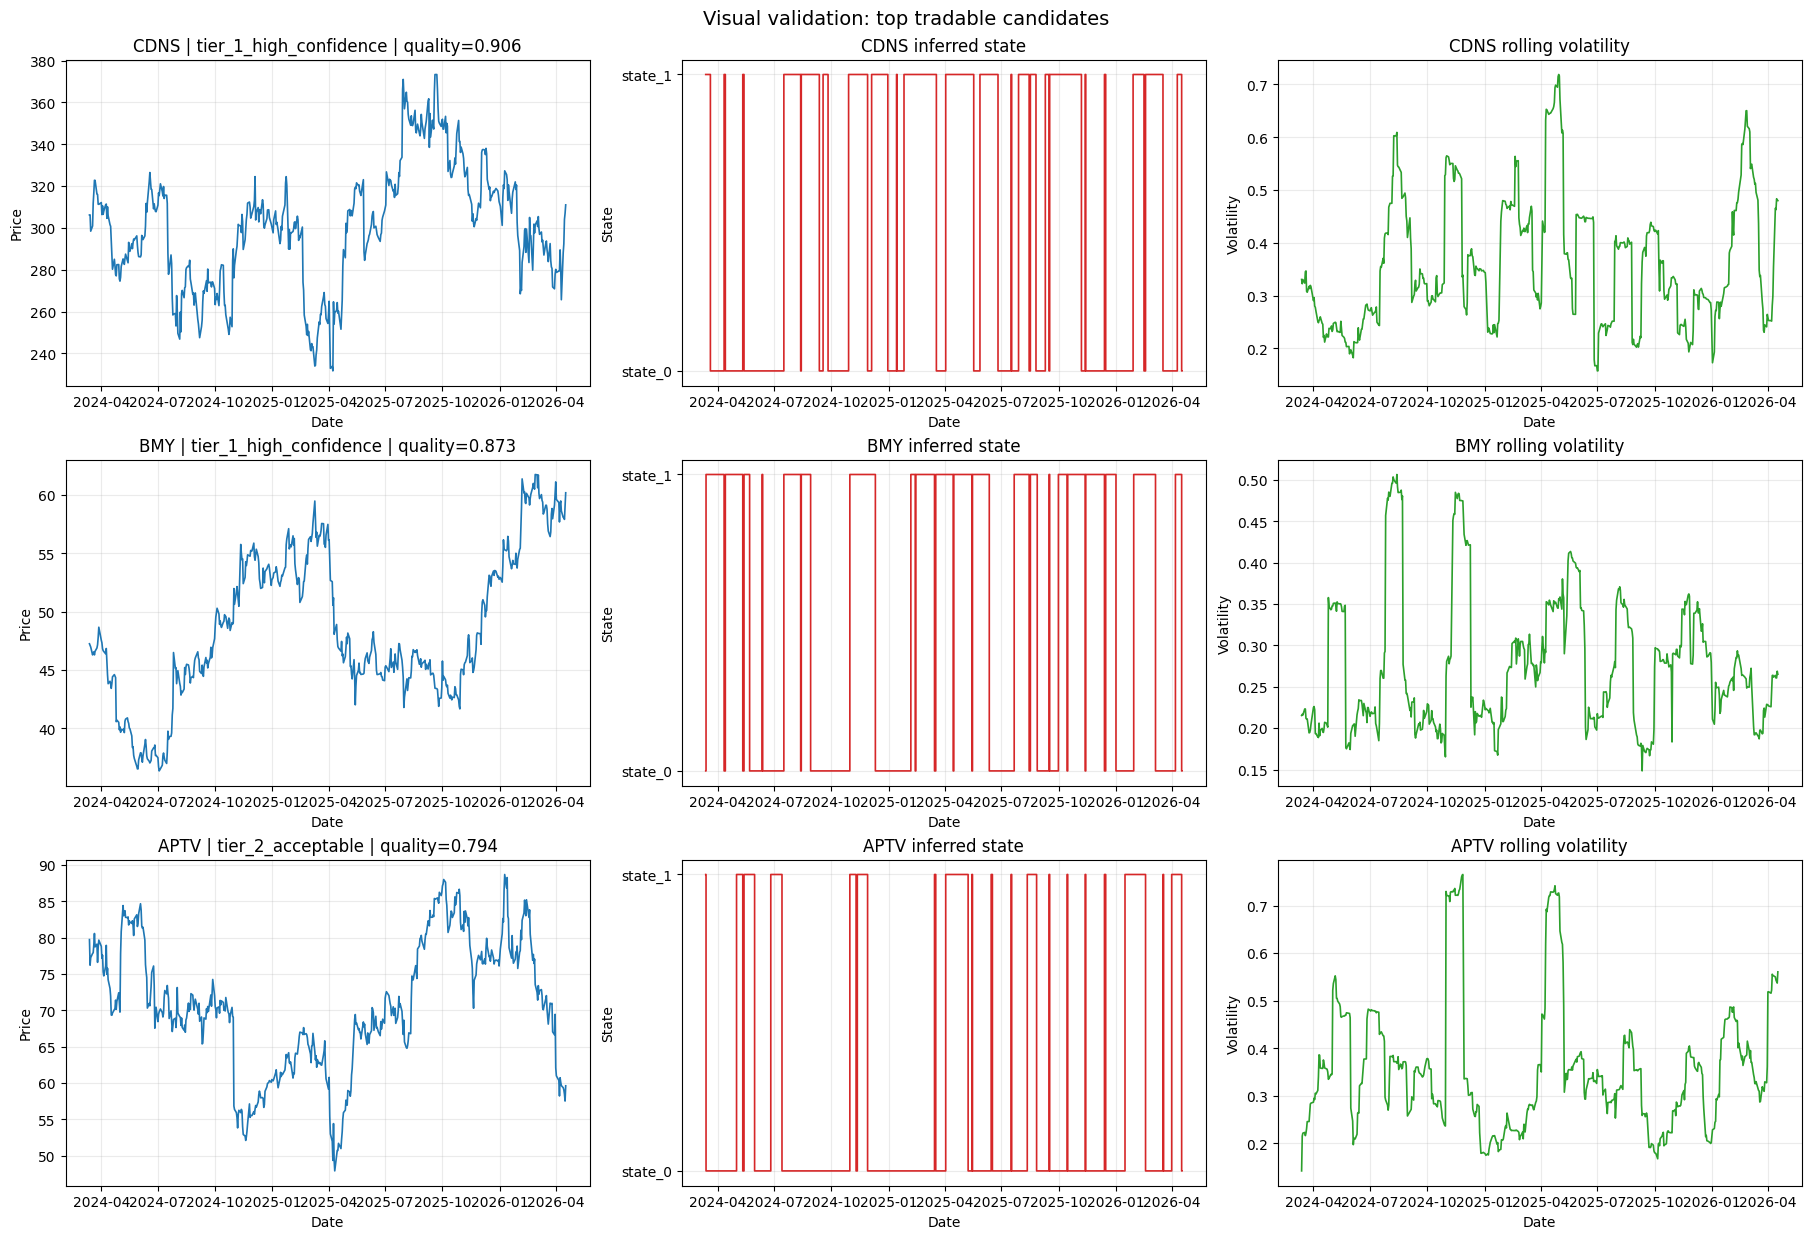

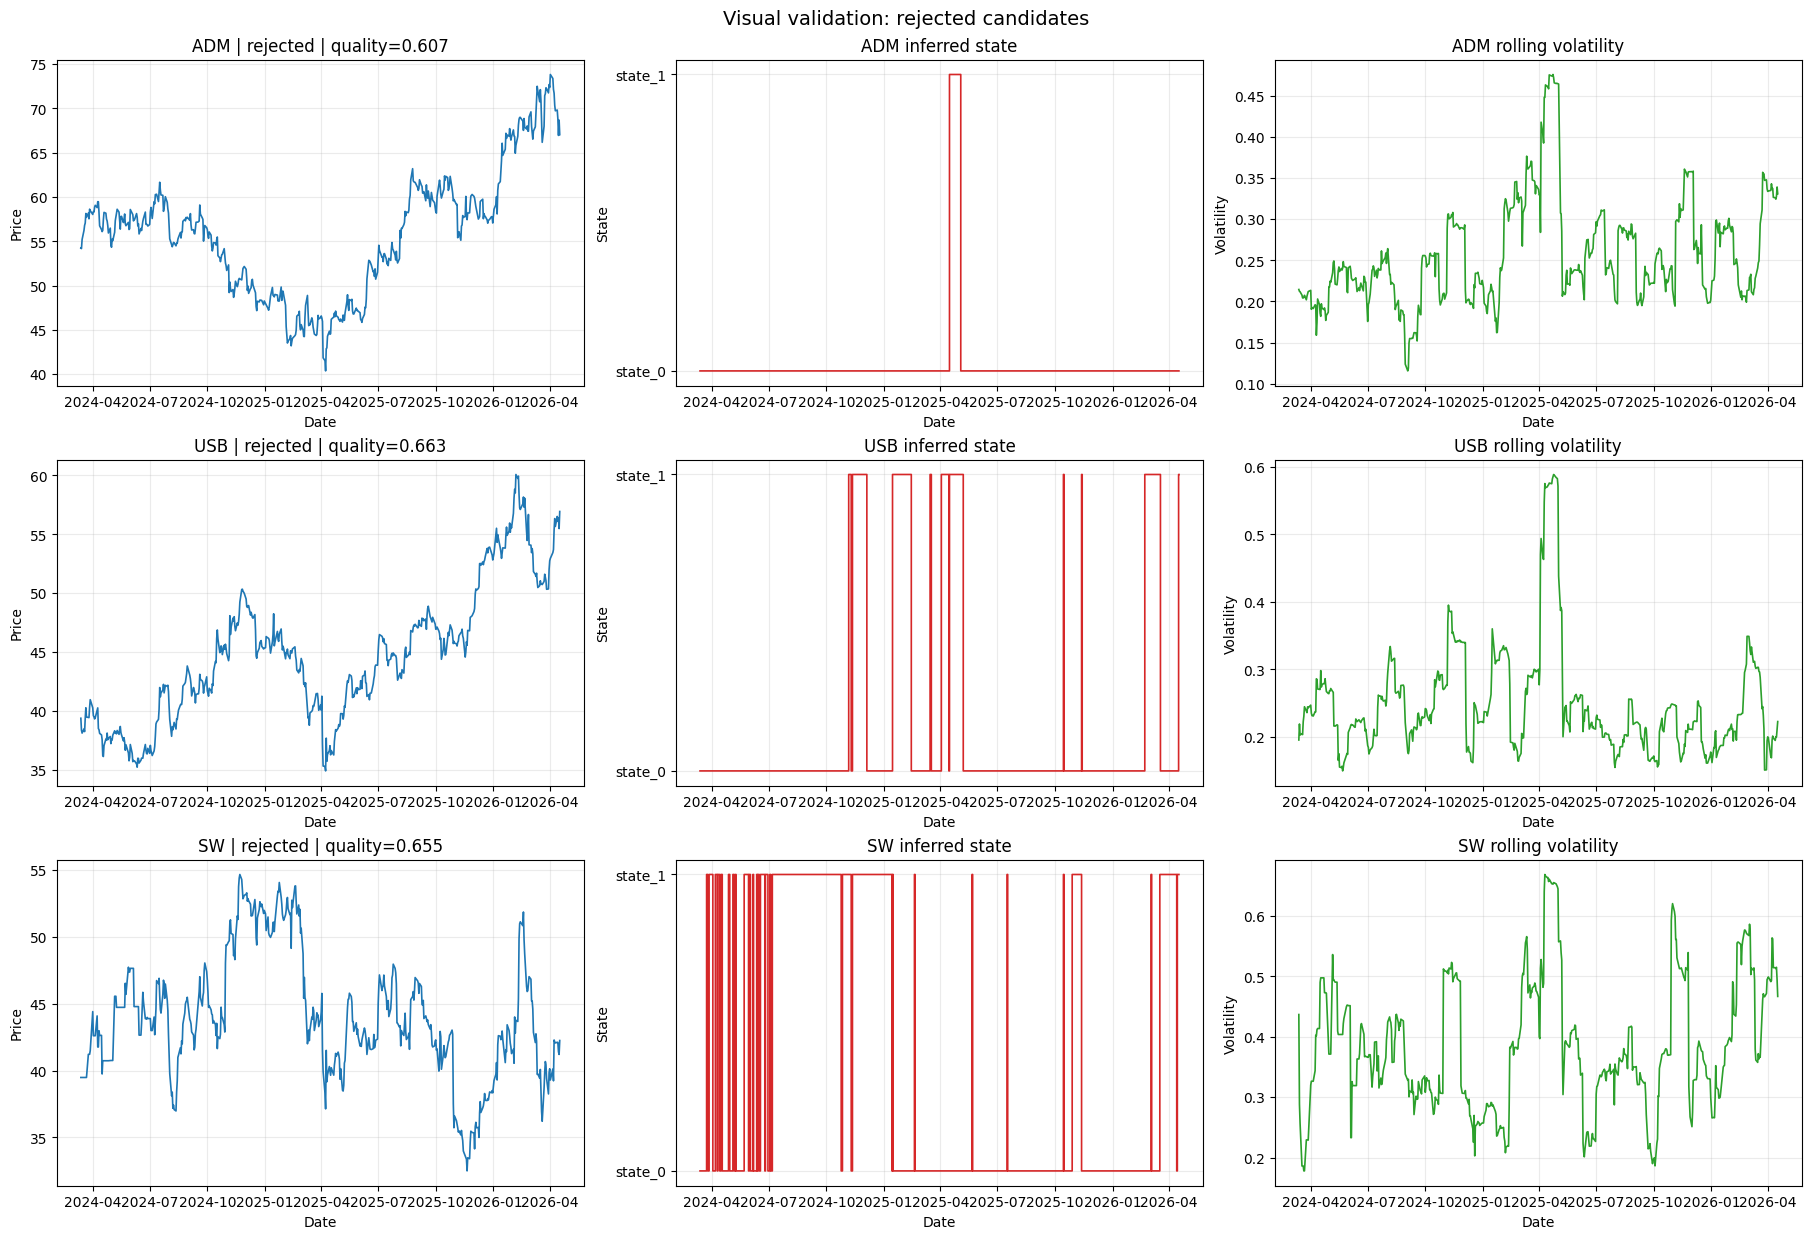

In [29]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

tier_1_max_degeneracy = 0.20
preferred_top_symbols = ["CDNS", "BMY", "APTV"]
preferred_rejected_symbols = ["ADM", "USB", "SW"]
visual_validation_count = 3

candidate_tier_panel = candidate_panel.copy()
candidate_tier_panel["candidate_tier"] = "rejected"
candidate_tier_panel.loc[
    candidate_tier_panel["passes_tradable_filters"]
    & candidate_tier_panel["degeneracy_rate"].lt(tier_1_max_degeneracy),
    "candidate_tier",
] = "tier_1_high_confidence"
candidate_tier_panel.loc[
    candidate_tier_panel["passes_tradable_filters"]
    & candidate_tier_panel["degeneracy_rate"].ge(tier_1_max_degeneracy)
    & candidate_tier_panel["degeneracy_rate"].lt(candidate_filter_config["max_degeneracy_rate"]),
    "candidate_tier",
] = "tier_2_acceptable"

tier_1_candidates = candidate_tier_panel.loc[
    candidate_tier_panel["candidate_tier"] == "tier_1_high_confidence"
].sort_values(
    ["overall_quality_score", "mean_state_separability", "mean_state_persistence"],
    ascending=[False, False, False],
    na_position="last",
).reset_index(drop=True)

tier_2_candidates = candidate_tier_panel.loc[
    candidate_tier_panel["candidate_tier"] == "tier_2_acceptable"
].sort_values(
    ["overall_quality_score", "mean_state_separability", "mean_state_persistence"],
    ascending=[False, False, False],
    na_position="last",
).reset_index(drop=True)

def choose_symbols(frame: pd.DataFrame, preferred: list[str], count: int) -> list[str]:
    available_symbols = frame["symbol"].tolist()
    chosen = [symbol for symbol in preferred if symbol in available_symbols]
    for symbol in available_symbols:
        if symbol not in chosen:
            chosen.append(symbol)
        if len(chosen) >= count:
            break
    return chosen[:count]

selected_top_symbols = choose_symbols(
    pd.concat([tier_1_candidates, tier_2_candidates], ignore_index=True),
    preferred_top_symbols,
    visual_validation_count,
 )
selected_rejected_symbols = choose_symbols(
    rejected_regime_candidates,
    preferred_rejected_symbols,
    visual_validation_count,
 )

selected_symbols = selected_top_symbols + selected_rejected_symbols
plot_state_map = {"state_0": 0.0, "state_1": 1.0}

def plot_regime_validation(symbols_to_plot: list[str], title_prefix: str) -> None:
    if not symbols_to_plot:
        print(f"No symbols available for {title_prefix.lower()} plotting.")
        return

    figure, axes = plt.subplots(
        len(symbols_to_plot),
        3,
        figsize=(18, 4 * len(symbols_to_plot)),
        sharex=False,
        constrained_layout=True,
    )
    if len(symbols_to_plot) == 1:
        axes = np.array([axes])

    for row_index, symbol in enumerate(symbols_to_plot):
        state_series = state_sequence_panel.get(symbol)
        price_series = clean_price_panel.get(symbol)
        volatility_series = rolling_vol_panel.get(symbol)

        if state_series is None or price_series is None or volatility_series is None:
            continue

        state_series = state_series.dropna()
        if state_series.empty:
            continue

        plot_index = state_series.index
        aligned_price = price_series.reindex(plot_index)
        aligned_volatility = volatility_series.reindex(plot_index)
        aligned_state = state_series.map(plot_state_map).astype(float)

        quality_row = candidate_tier_panel.loc[candidate_tier_panel["symbol"] == symbol].iloc[0]
        symbol_title = (
            f"{symbol} | {quality_row['candidate_tier']} | "
            f"quality={quality_row['overall_quality_score']:.3f}"
        )

        axes[row_index, 0].plot(plot_index, aligned_price, color="#1f77b4", linewidth=1.2)
        axes[row_index, 0].set_title(symbol_title)
        axes[row_index, 0].set_ylabel("Price")
        axes[row_index, 0].grid(alpha=0.25)

        axes[row_index, 1].step(plot_index, aligned_state, where="mid", color="#d62728", linewidth=1.2)
        axes[row_index, 1].set_title(f"{symbol} inferred state")
        axes[row_index, 1].set_ylabel("State")
        axes[row_index, 1].set_yticks([0, 1], labels=["state_0", "state_1"])
        axes[row_index, 1].grid(alpha=0.25)

        axes[row_index, 2].plot(plot_index, aligned_volatility, color="#2ca02c", linewidth=1.2)
        axes[row_index, 2].set_title(f"{symbol} rolling volatility")
        axes[row_index, 2].set_ylabel("Volatility")
        axes[row_index, 2].grid(alpha=0.25)

        for column_index in range(3):
            axes[row_index, column_index].set_xlabel("Date")

    figure.suptitle(title_prefix, fontsize=14, y=1.02)
    plt.show()

tier_summary = {
    "tier_1_high_confidence": int(len(tier_1_candidates)),
    "tier_2_acceptable": int(len(tier_2_candidates)),
    "rejected": int((candidate_tier_panel["candidate_tier"] == "rejected").sum()),
    "tier_1_max_degeneracy": tier_1_max_degeneracy,
    "selected_top_symbols": selected_top_symbols,
    "selected_rejected_symbols": selected_rejected_symbols,
}

print(json.dumps(tier_summary, indent=2))
display(
    candidate_tier_panel[[
        "symbol",
        "candidate_tier",
        "overall_quality_score",
        "degeneracy_rate",
        "mean_state_persistence",
        "mean_state_separability",
        "state_0_share",
        "state_1_share",
    ]].head(15)
)
display(tier_1_candidates.head(15))
display(tier_2_candidates.head(15))

plot_regime_validation(selected_top_symbols, "Visual validation: top tradable candidates")
plot_regime_validation(selected_rejected_symbols, "Visual validation: rejected candidates")

## Single-Ticker Diagnostic Follow-Up

This section turns the earlier CDNS audit into a reusable single-ticker diagnostic.

Set `target_symbol` in the next cell and rerun it to inspect any stock that made it through the feature and HMM pipeline.

The diagnostic checks two things directly:

- the canonical HMM emissions, to confirm that the two states are meaningfully different
- the timing of the degenerate walk-forward blocks, to see whether they are clustered in one market episode or scattered through the sample

This keeps the broader shortlist logic intact while giving you a focused follow-up for any individual name.

In [31]:
import json
import numpy as np
import pandas as pd

target_symbol = "CDNS"


def build_single_ticker_diagnostic(target_symbol: str) -> dict[str, object]:
    target_symbol = str(target_symbol).upper()

    quality_match = candidate_tier_panel.loc[candidate_tier_panel["symbol"] == target_symbol].copy()
    summary_match = stock_hmm_summary.loc[stock_hmm_summary["symbol"] == target_symbol].copy()
    parameter_match = hmm_parameter_panel.loc[hmm_parameter_panel["symbol"] == target_symbol].sort_values("train_end").copy()
    feature_match = complete_feature_panel.loc[
        complete_feature_panel["symbol"] == target_symbol
    ].sort_values("date").reset_index(drop=True)

    if quality_match.empty or summary_match.empty:
        raise ValueError(f"{target_symbol} is missing from the candidate or fit summary tables.")

    if parameter_match.empty:
        raise ValueError(f"{target_symbol} has no stored HMM parameter rows to inspect.")

    quality_row = quality_match.iloc[0]
    summary_row = summary_match.iloc[0]

    emission_rows = []
    for parameter_row in parameter_match.itertuples(index=False):
        emission_means = np.asarray(parameter_row.emission_means, dtype=float)
        emission_covariances = np.asarray(parameter_row.emission_covariances, dtype=float)

        for state_index in range(hmm_n_states):
            record = {
                "train_end": parameter_row.train_end,
                "infer_start": parameter_row.infer_start,
                "infer_end": parameter_row.infer_end,
                "state": f"state_{state_index}",
                "degenerate_block": bool(parameter_row.degenerate_block),
            }
            for feature_index, feature_name in enumerate(feature_columns):
                record[f"mean_{feature_name}"] = float(emission_means[state_index, feature_index])
                record[f"var_{feature_name}"] = float(emission_covariances[state_index, feature_index])
            emission_rows.append(record)

    emission_panel = pd.DataFrame(emission_rows).sort_values(["train_end", "state"]).reset_index(drop=True)
    emission_summary = (
        emission_panel.groupby("state")[
            [
                f"mean_{feature_name}" for feature_name in feature_columns
            ] + [
                f"var_{feature_name}" for feature_name in feature_columns
            ]
        ]
        .agg(["mean", "median", "min", "max"])
        .round(4)
    )

    expected_windows = []
    for train_end_index in range(hmm_train_window, len(feature_match), hmm_forward_window):
        infer_end_index = min(train_end_index + hmm_forward_window, len(feature_match))
        infer_slice = feature_match.iloc[train_end_index:infer_end_index]
        if infer_slice.empty:
            continue
        expected_windows.append(
            {
                "train_start": feature_match["date"].iloc[train_end_index - hmm_train_window],
                "train_end": feature_match["date"].iloc[train_end_index - 1],
                "infer_start": infer_slice["date"].iloc[0],
                "infer_end": infer_slice["date"].iloc[-1],
                "trading_days": int(len(infer_slice)),
            }
        )

    window_schedule = pd.DataFrame(expected_windows)
    window_audit = window_schedule.merge(
        parameter_match[[
            "train_start",
            "train_end",
            "infer_start",
            "infer_end",
            "degenerate_block",
            "transition_matrix",
        ]],
        on=["train_start", "train_end", "infer_start", "infer_end"],
        how="left",
    )
    window_audit["window_status"] = np.where(
        window_audit["degenerate_block"].eq(True),
        "degenerate_block",
        np.where(window_audit["degenerate_block"].isna(), "fit_failed_or_skipped", "ok"),
    )
    window_audit["calendar_days"] = (window_audit["infer_end"] - window_audit["infer_start"]).dt.days + 1

    problem_windows = window_audit.loc[
        window_audit["window_status"] != "ok",
        [
            "train_start",
            "train_end",
            "infer_start",
            "infer_end",
            "trading_days",
            "calendar_days",
            "window_status",
        ],
    ].reset_index(drop=True)

    latest_emissions = (
        emission_panel.sort_values("train_end")
        .groupby("state", as_index=False)
        .tail(1)
        .sort_values("state")
        .reset_index(drop=True)
    )

    summary = {
        "symbol": target_symbol,
        "candidate_tier": quality_row["candidate_tier"],
        "overall_quality_score": round(float(quality_row["overall_quality_score"]), 4),
        "degeneracy_rate": round(float(quality_row["degeneracy_rate"]), 4),
        "mean_state_persistence": round(float(quality_row["mean_state_persistence"]), 4),
        "mean_state_separability": round(float(quality_row["mean_state_separability"]), 4),
        "state_0_share": round(float(quality_row["state_0_share"]), 4),
        "state_1_share": round(float(quality_row["state_1_share"]), 4),
        "completed_refits": int(summary_row["refit_count"]),
        "degenerate_blocks": int(summary_row["degenerate_blocks"]),
        "problem_windows": int(len(problem_windows)),
        "problem_window_status_counts": window_audit["window_status"].value_counts().to_dict(),
        "latest_inference_window": {
            "infer_start": parameter_match["infer_start"].max().date().isoformat(),
            "infer_end": parameter_match["infer_end"].max().date().isoformat(),
        },
    }

    return {
        "summary": summary,
        "quality_row": quality_row,
        "summary_row": summary_row,
        "emission_panel": emission_panel,
        "emission_summary": emission_summary,
        "latest_emissions": latest_emissions,
        "window_audit": window_audit,
        "problem_windows": problem_windows,
    }


ticker_diagnostic = build_single_ticker_diagnostic(target_symbol)
ticker_emission_panel = ticker_diagnostic["emission_panel"]
ticker_emission_summary = ticker_diagnostic["emission_summary"]
ticker_latest_emissions = ticker_diagnostic["latest_emissions"]
ticker_window_audit = ticker_diagnostic["window_audit"]
ticker_problem_windows = ticker_diagnostic["problem_windows"]

print(json.dumps(ticker_diagnostic["summary"], indent=2))
display(ticker_emission_summary)
display(ticker_latest_emissions[[
    "state",
    *[f"mean_{feature_name}" for feature_name in feature_columns],
    *[f"var_{feature_name}" for feature_name in feature_columns],
]])
display(ticker_problem_windows)

{
  "symbol": "CDNS",
  "candidate_tier": "tier_1_high_confidence",
  "overall_quality_score": 0.906,
  "degeneracy_rate": 0.1538,
  "mean_state_persistence": 0.976,
  "mean_state_separability": 2.9708,
  "state_0_share": 0.4677,
  "state_1_share": 0.5323,
  "completed_refits": 26,
  "degenerate_blocks": 4,
  "problem_windows": 4,
  "problem_window_status_counts": {
    "ok": 22,
    "degenerate_block": 4
  },
  "latest_inference_window": {
    "infer_start": "2026-04-17",
    "infer_end": "2026-04-17"
  }
}


mean_log_return_1d                         mean_rolling_vol_20d  \
                      mean  median     min     max                 mean   
state                                                                     
state_0             0.0256  0.0263  0.0081  0.0416              -0.6716   
state_1            -0.0403 -0.0399 -0.0701 -0.0090               1.0493   

                                mean_volume_change_z_20d          ...  \
         median     min     max                     mean  median  ...   
state                                                             ...   
state_0 -0.6771 -0.7802 -0.5920                   0.0069  0.0083  ...   
state_1  1.0466  0.8246  1.2898                  -0.0115 -0.0140  ...   

        var_log_return_1d         var_rolling_vol_20d                          \
                      min     max                mean  median     min     max   
state                                                                           
state_0            0.5084  0.5922              0.1454  0.1506  0.0923  0.1930   
state_1            1.5216  1.9178              0.5371  0.5271  0.3064  0.7401   

        var_volume_change_z_20d                          
                           mean  median     min     max  
state                                                    
state_0                  0.9835  0.9863  0.9462  1.0206  
state_1                  1.0257  1.0215  0.9747  1.0973  

[2 rows x 24 columns]

,state,mean_log_return_1d,mean_rolling_vol_20d,mean_volume_change_z_20d,var_log_return_1d,var_rolling_vol_20d,var_volume_change_z_20d
0,state_0,0.027841,-0.625852,0.015293,0.538307,0.139665,1.000526
1,state_1,-0.050414,1.133266,-0.027691,1.832143,0.564383,0.997932


,train_start,train_end,infer_start,infer_end,trading_days,calendar_days,window_status
0,2021-06-10,2024-06-11,2024-06-12,2024-07-12,21,31,degenerate_block
1,2022-02-08,2025-02-12,2025-02-13,2025-03-14,21,30,degenerate_block
2,2022-04-08,2025-04-14,2025-04-15,2025-05-14,21,30,degenerate_block
3,2023-04-12,2026-04-16,2026-04-17,2026-04-17,1,1,degenerate_block


## Cross-Candidate Degeneracy Clustering Audit

A single ticker can look episodically degenerate for stock-specific reasons, but the bigger question is whether that pattern is shared across the broader tradable candidate list.

This audit asks whether degenerate walk-forward blocks are concentrated in recent windows, especially from 2024 onward, or spread more evenly through history.

Why this matters:
- If recent clustering is widespread, the issue may be systemic rather than ticker-specific.
- That would suggest the current walk-forward training windows are struggling to adapt to a newer macro regime.
- If clustering is isolated to a few names, the shortlist is probably facing stock-level instability rather than a broad modeling failure.

The next cell measures recent-versus-historical degeneracy concentration across the current tradable candidate set.

In [33]:
import json
import numpy as np
import pandas as pd

macro_cluster_start = pd.Timestamp("2024-01-01")
fallback_cluster_start = pd.Timestamp("2025-01-01")
min_degenerate_blocks_for_flag = 2

candidate_symbol_set = set(tradable_regime_candidates["symbol"])
candidate_parameter_panel = hmm_parameter_panel.loc[
    hmm_parameter_panel["symbol"].isin(candidate_symbol_set)
].copy()

if candidate_parameter_panel.empty:
    raise RuntimeError("No parameter history is available for the tradable candidate set.")

candidate_parameter_panel["infer_start"] = pd.to_datetime(candidate_parameter_panel["infer_start"])
candidate_parameter_panel["infer_end"] = pd.to_datetime(candidate_parameter_panel["infer_end"])
candidate_parameter_panel["degenerate_block"] = candidate_parameter_panel["degenerate_block"].fillna(False).astype(bool)
candidate_parameter_panel["infer_year"] = candidate_parameter_panel["infer_start"].dt.year

earliest_infer_start = candidate_parameter_panel["infer_start"].min()
latest_infer_end = candidate_parameter_panel["infer_end"].max()

if earliest_infer_start < macro_cluster_start:
    comparison_start = macro_cluster_start
    comparison_mode = "2024_onward_vs_pre_2024_history"
    comparison_note = (
        "Inference windows begin before 2024, so the notebook can directly test whether degeneracy becomes unusually concentrated from 2024 onward."
    )
else:
    comparison_start = max(fallback_cluster_start, earliest_infer_start)
    comparison_mode = "fallback_recent_vs_early_inference"
    comparison_note = (
        "Walk-forward inference does not begin before 2024 in this notebook, so a true 2024-versus-history audit is not available. "
        "The fallback split compares later inference windows against the earliest available inference period instead."
    )

candidate_parameter_panel["is_late_window"] = candidate_parameter_panel["infer_start"] >= comparison_start
degenerate_panel = candidate_parameter_panel.loc[candidate_parameter_panel["degenerate_block"]].copy()

candidate_cluster_rows: list[dict[str, object]] = []
for symbol, symbol_frame in candidate_parameter_panel.groupby("symbol", sort=True):
    quality_row = candidate_tier_panel.loc[candidate_tier_panel["symbol"] == symbol].iloc[0]
    total_windows = int(len(symbol_frame))
    total_degenerate_blocks = int(symbol_frame["degenerate_block"].sum())
    late_windows = int(symbol_frame["is_late_window"].sum())
    early_windows = int(total_windows - late_windows)
    late_degenerate_blocks = int(symbol_frame.loc[symbol_frame["is_late_window"], "degenerate_block"].sum())
    early_degenerate_blocks = int(total_degenerate_blocks - late_degenerate_blocks)

    late_window_share = late_windows / total_windows if total_windows else np.nan
    late_degenerate_share = (
        late_degenerate_blocks / total_degenerate_blocks if total_degenerate_blocks else np.nan
    )
    concentration_ratio = (
        late_degenerate_share / late_window_share
        if total_degenerate_blocks and np.isfinite(late_window_share) and late_window_share > 0
        else np.nan
    )

    if total_degenerate_blocks == 0:
        clustering_label = "no_degenerate_blocks"
    elif late_degenerate_blocks == total_degenerate_blocks and total_degenerate_blocks >= min_degenerate_blocks_for_flag:
        clustering_label = "all_late"
    elif late_degenerate_share >= 0.75 and total_degenerate_blocks >= min_degenerate_blocks_for_flag:
        clustering_label = "mostly_late"
    elif early_degenerate_blocks == total_degenerate_blocks and total_degenerate_blocks >= min_degenerate_blocks_for_flag:
        clustering_label = "early_only"
    else:
        clustering_label = "mixed"

    candidate_cluster_rows.append(
        {
            "symbol": symbol,
            "candidate_tier": quality_row["candidate_tier"],
            "overall_quality_score": float(quality_row["overall_quality_score"]),
            "total_windows": total_windows,
            "late_windows": late_windows,
            "early_windows": early_windows,
            "total_degenerate_blocks": total_degenerate_blocks,
            "late_degenerate_blocks": late_degenerate_blocks,
            "early_degenerate_blocks": early_degenerate_blocks,
            "late_window_share": round(float(late_window_share), 4) if np.isfinite(late_window_share) else None,
            "late_degenerate_share": round(float(late_degenerate_share), 4) if np.isfinite(late_degenerate_share) else None,
            "late_concentration_ratio": round(float(concentration_ratio), 4) if np.isfinite(concentration_ratio) else None,
            "clustering_label": clustering_label,
        }
    )

degeneracy_clustering_panel = pd.DataFrame(candidate_cluster_rows).sort_values(
    ["late_concentration_ratio", "total_degenerate_blocks", "overall_quality_score"],
    ascending=[False, False, False],
    na_position="last",
).reset_index(drop=True)

degenerate_block_year_counts = (
    degenerate_panel.groupby("infer_year").size().rename("degenerate_blocks").to_frame()
    if not degenerate_panel.empty
    else pd.DataFrame(columns=["degenerate_blocks"])
 )

degenerate_block_symbol_year_counts = (
    degenerate_panel.groupby(["infer_year", "symbol"]).size().groupby("infer_year").size()
    .rename("symbols_with_degenerate_blocks").to_frame()
    if not degenerate_panel.empty
    else pd.DataFrame(columns=["symbols_with_degenerate_blocks"])
 )

degenerate_block_year_summary = degenerate_block_year_counts.join(
    degenerate_block_symbol_year_counts,
    how="outer",
).fillna(0).astype(int)

clustered_late_candidates = degeneracy_clustering_panel.loc[
    degeneracy_clustering_panel["clustering_label"].isin(["all_late", "mostly_late"])
]

macro_degeneracy_summary = {
    "comparison_mode": comparison_mode,
    "comparison_start": comparison_start.date().isoformat(),
    "earliest_inference_window": earliest_infer_start.date().isoformat(),
    "latest_inference_window": latest_infer_end.date().isoformat(),
    "comparison_note": comparison_note,
    "tradable_candidates": int(len(degeneracy_clustering_panel)),
    "candidates_with_any_degenerate_blocks": int(
        (degeneracy_clustering_panel["total_degenerate_blocks"] > 0).sum()
    ),
    "candidates_with_late_clustered_degeneracy": int(len(clustered_late_candidates)),
    "candidates_with_all_late_degeneracy": int(
        (degeneracy_clustering_panel["clustering_label"] == "all_late").sum()
    ),
    "candidates_with_mostly_late_degeneracy": int(
        (degeneracy_clustering_panel["clustering_label"] == "mostly_late").sum()
    ),
    "candidates_with_mixed_degeneracy": int(
        (degeneracy_clustering_panel["clustering_label"] == "mixed").sum()
    ),
    "candidates_with_early_only_degeneracy": int(
        (degeneracy_clustering_panel["clustering_label"] == "early_only").sum()
    ),
    "overall_late_window_share": round(
        float(candidate_parameter_panel["is_late_window"].mean()),
        4,
    ),
    "overall_late_degenerate_share": (
        round(float(degenerate_panel["is_late_window"].mean()), 4)
        if not degenerate_panel.empty
        else None
    ),
    "late_clustered_symbols": clustered_late_candidates["symbol"].head(15).tolist(),
}

print(json.dumps(macro_degeneracy_summary, indent=2))
display(degenerate_block_year_summary)
display(
    degeneracy_clustering_panel[[
        "symbol",
        "candidate_tier",
        "overall_quality_score",
        "total_degenerate_blocks",
        "late_degenerate_blocks",
        "early_degenerate_blocks",
        "late_window_share",
        "late_degenerate_share",
        "late_concentration_ratio",
        "clustering_label",
    ]].head(20)
)
display(
    clustered_late_candidates[[
        "symbol",
        "candidate_tier",
        "overall_quality_score",
        "total_degenerate_blocks",
        "late_degenerate_blocks",
        "early_degenerate_blocks",
        "late_degenerate_share",
        "late_concentration_ratio",
        "clustering_label",
    ]].reset_index(drop=True)
)

{
  "comparison_mode": "fallback_recent_vs_early_inference",
  "comparison_start": "2025-01-01",
  "earliest_inference_window": "2024-03-13",
  "latest_inference_window": "2026-04-17",
  "comparison_note": "Walk-forward inference does not begin before 2024 in this notebook, so a true 2024-versus-history audit is not available. The fallback split compares later inference windows against the earliest available inference period instead.",
  "tradable_candidates": 49,
  "candidates_with_any_degenerate_blocks": 49,
  "candidates_with_late_clustered_degeneracy": 9,
  "candidates_with_all_late_degeneracy": 4,
  "candidates_with_mostly_late_degeneracy": 5,
  "candidates_with_mixed_degeneracy": 40,
  "candidates_with_early_only_degeneracy": 0,
  "overall_late_window_share": 0.6154,
  "overall_late_degenerate_share": 0.5677,
  "late_clustered_symbols": [
    "LULU",
    "EQT",
    "COR",
    "FIX",
    "LLY",
    "HUM",
    "IR",
    "WM",
    "CDNS"
  ]
}


,degenerate_blocks,symbols_with_degenerate_blocks
infer_year,,
2024,134,45
2025,100,45
2026,76,49


,symbol,candidate_tier,overall_quality_score,total_degenerate_blocks,late_degenerate_blocks,early_degenerate_blocks,late_window_share,late_degenerate_share,late_concentration_ratio,clustering_label
0,LULU,tier_2_acceptable,0.8662,7,7,0,0.6154,1.0000,1.6250,all_late
1,EQT,tier_2_acceptable,0.8484,6,6,0,0.6154,1.0000,1.6250,all_late
2,COR,tier_1_high_confidence,0.8859,5,5,0,0.6154,1.0000,1.6250,all_late
3,FIX,tier_1_high_confidence,0.8178,4,4,0,0.6154,1.0000,1.6250,all_late
4,LLY,tier_2_acceptable,0.8850,6,5,1,0.6154,0.8333,1.3542,mostly_late
5,HUM,tier_2_acceptable,0.8199,6,5,1,0.6154,0.8333,1.3542,mostly_late
6,IR,tier_1_high_confidence,0.8844,5,4,1,0.6154,0.8000,1.3000,mostly_late
7,WM,tier_1_high_confidence,0.8779,5,4,1,0.6154,0.8000,1.3000,mostly_late
8,CDNS,tier_1_high_confidence,0.9060,4,3,1,0.6154,0.7500,1.2188,mostly_late
9,CVS,tier_2_acceptable,0.8679,7,5,2,0.6154,0.7143,1.1607,mixed


,symbol,candidate_tier,overall_quality_score,total_degenerate_blocks,late_degenerate_blocks,early_degenerate_blocks,late_degenerate_share,late_concentration_ratio,clustering_label
0,LULU,tier_2_acceptable,0.8662,7,7,0,1.0000,1.6250,all_late
1,EQT,tier_2_acceptable,0.8484,6,6,0,1.0000,1.6250,all_late
2,COR,tier_1_high_confidence,0.8859,5,5,0,1.0000,1.6250,all_late
3,FIX,tier_1_high_confidence,0.8178,4,4,0,1.0000,1.6250,all_late
4,LLY,tier_2_acceptable,0.8850,6,5,1,0.8333,1.3542,mostly_late
5,HUM,tier_2_acceptable,0.8199,6,5,1,0.8333,1.3542,mostly_late
6,IR,tier_1_high_confidence,0.8844,5,4,1,0.8000,1.3000,mostly_late
7,WM,tier_1_high_confidence,0.8779,5,4,1,0.8000,1.3000,mostly_late
8,CDNS,tier_1_high_confidence,0.9060,4,3,1,0.7500,1.2188,mostly_late
